MLP Accuracy: 99.09%


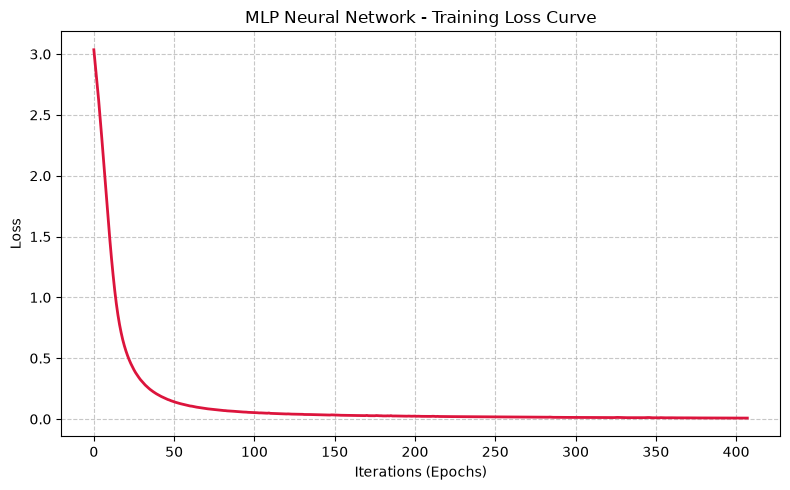

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. โหลดข้อมูล
df = pd.read_csv('crop_fertilizer_recommendation_dataset.csv')
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
target = 'label'

X = df[features]
y = df[target]

# 2. แบ่งข้อมูลและทำ Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. เทรนโมเดล MLP
model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
model.fit(X_train_scaled, y_train)

# 4. ประเมินผล
y_pred = model.predict(X_test_scaled)
print(f"MLP Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 5. พล็อตกราฟ Loss Curve ตลอดการ Epoch
plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_, color='crimson', linewidth=2)
plt.title('MLP Neural Network - Training Loss Curve')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()